## Korteweg-De Vries Dynamics

### Configuration

In [1]:
from __init__ import create_config, figures
from IPython.display import display

config = create_config(
    system="kdv",
    n_states=16,
    seed=31,
)
cache_dir = f"./cache_seed{config.seed}"
figures.save_config_table(config)
figures.show_spec(config, keys=["system", "seed", "n_states", "n_controls", "t1_initial"])

system,seed,n_states,n_controls,t1_initial
kdv,31,16,2,5.000000


### Data Generation

In [2]:
# Configure which controllers to enable/disable
# Use the exact names from DEFAULT_CONTROLLER_CONFIGS in model_factory.py
controller_configs = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (sup)": {"enabled": True},
    "GradQRNet (pre)": {"enabled": True},  # Hybrid (pretraining)
    "GradQRNet (ad)": {"enabled": True},  # Adaptive sampling
}

# If controller_configs is None, all defaults from model_factory.py are used
# If you provide a dict, it will merge with defaults (partial overrides are allowed)

trajectories,data points,t (min),t (max),|x| (mean),|x| (max),||x|| (mean),||x|| (max)
1,25,0.000000,0.009784,0.019374,0.102036,0.065634,0.065712


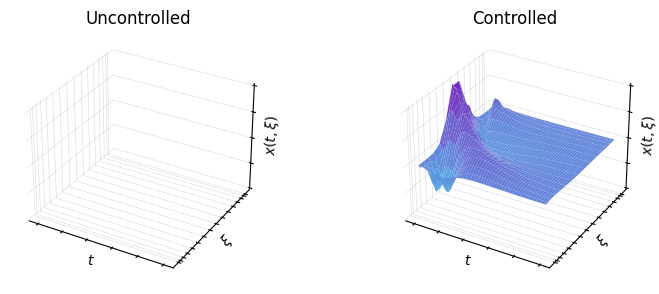

In [3]:
import matplotlib.pyplot as plt
from data import load_or_generate

data_train, data_val, meta = load_or_generate(config, n_trajectories=1, controller=config.ocp.LQR)
data = data_train  # Keep using 'data' for backward compatibility

summary_df = figures.save_data_summary_table(config, data)

display(summary_df.style.hide(axis="index"))

fig = figures.plot_3d(config=config, controller=config.ocp.LQR)
plt.show()

### Model Training

In [4]:
from controls.model_factory import train_or_load_gradnet
from controls.train import TrainConfig

cfg = TrainConfig(batch_size=int(config.n_states), horizon=30, unsup_n_steps=70) # old: 1.0

# 1. Save to LaTeX using the new generic function
figures.save_params_table(cfg, "traincfg.tex", title="Training Configuration", config=config)

# 2. Show in Notebook using the universal show_spec
figures.show_spec(
    cfg, 
    keys=["sup_epochs", "sup_lr", "unsup_epochs", "unsup_n_steps", "unsup_lr", "horizon", "batch_size", "grad_clip"], 
    title="Training Configuration"
)

**Training Configuration**

sup_epochs,sup_lr,unsup_epochs,unsup_n_steps,unsup_lr,horizon,batch_size,grad_clip
1,0.000010,5,70,0.000500,30,16,None


In [5]:
from controls.model_factory import train_controllers

trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg,
    data=data_train,  
    val_data=data_val,
    controller_configs=controller_configs,  # Use the config defined above
)

figures.plot_training_losses(
    series=[(name, hist) for name, hist in histories.items()],
    logy=True,
    smooth="ema",
    ema_alpha=0.03,
);


Training: GradQRNet


RuntimeError: mat1 and mat2 shapes cannot be multiplied (16x6 and 16x256)

### Evaluation: Stability and Optimality

In [ ]:
controllers = [
    ("LQR (Baseline)", config.ocp.LQR),
] + [(name, trained_controllers[name]) for name in trained_controllers.keys()]

In [ ]:
from simulation import monte_carlo

results = monte_carlo(config.ocp, config, controllers, n_MC=100)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config)

 29%|██▉       | 29/100 [00:54<01:47,  1.52s/it]capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.
 29%|██▉       | 29/100 [00:56<02:19,  1.96s/it]


KeyboardInterrupt: 

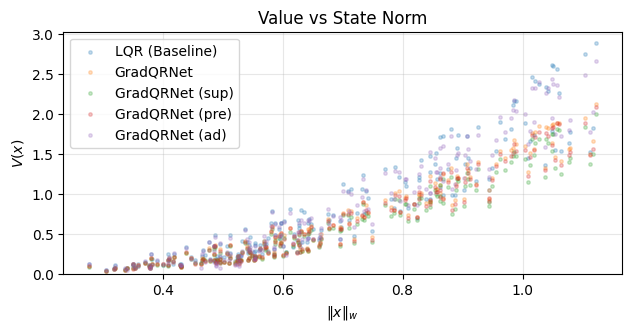

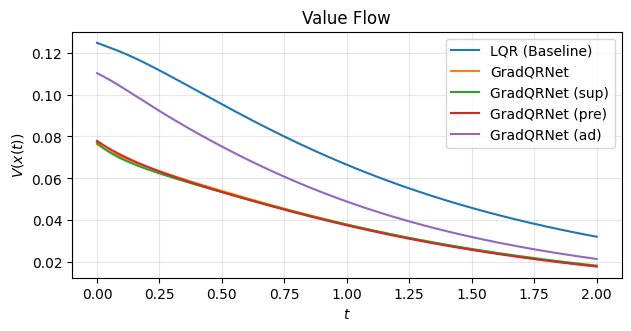

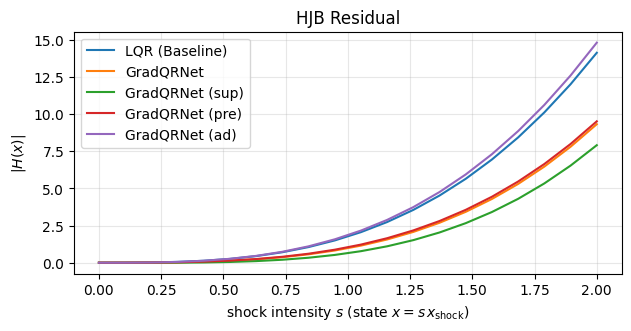

In [ ]:
figures.plot_value_analysis_combined(
    config=config,
    controllers=controllers,
    n=200,
    tspan=(0.0, 2.0),
    Nt=400,"
)
plt.show()

### Combined Architectures

In [ ]:
controller_configs = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (sup/ad)": {"enabled": True},
    "GradQRNet (pre/sup)": {"enabled": True},
    "GradQRNet (pre/ad)": {"enabled": True},
    "GradQRNet (pre/sup/ad)": {"enabled": True},
}


Training: GradQRNet

Training: GradQRNet (pre/sup)
epoch 0001 | loss=6.37e-01 | hjb=4.34e-01 | sup=6.37e-02 | bs=32 | heur=nan | val_mse=2.16e+00
epoch 0001 | loss=2.76e-01 | hjb=1.26e-01 | sup=6.10e-02 | bs=32 | heur=nan | val_mse=1.95e+00
epoch 0002 | loss=1.65e-01 | hjb=2.89e-02 | sup=5.56e-02 | bs=32 | heur=nan | val_mse=1.84e+00
epoch 0003 | loss=1.22e-01 | hjb=2.18e-02 | sup=5.24e-02 | bs=32 | heur=nan | val_mse=1.78e+00
epoch 0004 | loss=8.69e-02 | hjb=2.38e-02 | sup=5.07e-02 | bs=32 | heur=nan | val_mse=1.76e+00
epoch 0005 | loss=4.43e-02 | hjb=2.03e-02 | sup=5.11e-02 | bs=32 | heur=nan | val_mse=1.75e+00

Training: GradQRNet (sup/ad)
epoch 0001 | loss=3.72e-01 | hjb=2.64e-01 | sup=6.26e-02 | bs=32 | heur=nan | val_mse=2.06e+00
epoch 0002 | loss=1.68e-01 | hjb=1.86e-02 | sup=5.97e-02 | bs=32 | heur=nan | val_mse=2.00e+00
epoch 0003 | loss=1.28e-01 | hjb=1.78e-02 | sup=5.71e-02 | bs=32 | heur=nan | val_mse=1.97e+00
epoch 0004 | loss=1.14e-01 | hjb=4.59e-02 | sup=5.69e-02 | bs=3

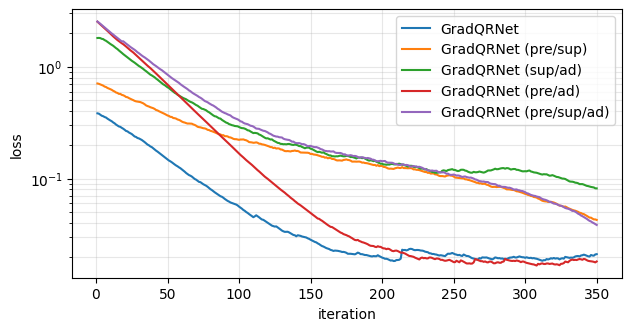

In [ ]:
trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg,
    data=data_train,  
    val_data=data_val,
    controller_configs=controller_configs,  # Use the config defined above
)

figures.plot_training_losses(
    series=[(name, hist) for name, hist in histories.items()],
    logy=True,
    smooth="ema",
    ema_alpha=0.03,
);

In [ ]:
controllers = [(name, trained_controllers[name]) for name in trained_controllers.keys()]

In [ ]:
results = monte_carlo(config.ocp, config, controllers, n_MC=100)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config)

100%|██████████| 100/100 [00:34<00:00,  2.88it/s]


Controller,Stability (S),Final ||X|| (mean),t_conv (mean),Cost J (mean)
GradQRNet,83.0%,0.0001,12.90,0.5058
GradQRNet (pre/sup),83.0%,0.0000,12.80,0.4873
GradQRNet (sup/ad),89.0%,0.0000,12.87,0.5705
GradQRNet (pre/ad),83.0%,0.0001,12.83,0.5076
GradQRNet (pre/sup/ad),84.0%,0.0001,12.59,0.5161


,Model,Stability $S$,$t_{\text{conv}}$ (mean),Cost $J$ (mean)
0,GradQRNet,0.83,12.896388,0.505796
1,GradQRNet (pre/sup),0.83,12.801771,0.487312
2,GradQRNet (sup/ad),0.89,12.868815,0.570492
3,GradQRNet (pre/ad),0.83,12.830219,0.507558
4,GradQRNet (pre/sup/ad),0.84,12.594515,0.516126


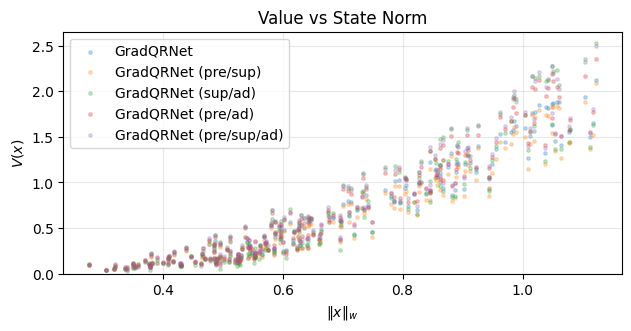

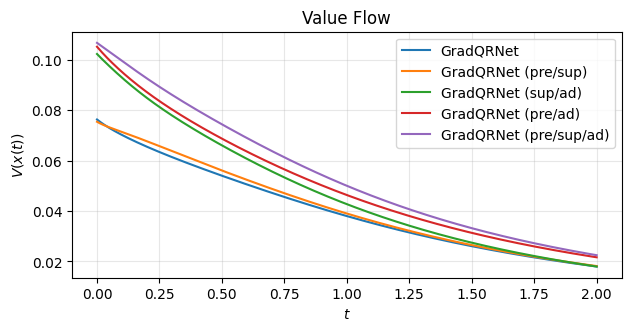

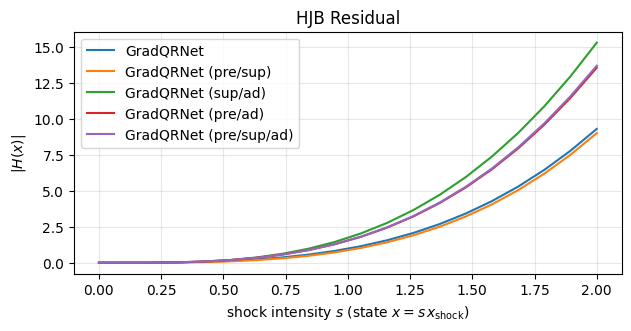

In [ ]:
figures.plot_value_analysis_combined(
    config=config,
    controllers=controllers,
    n=200,
    tspan=(0.0, 2.0),
    Nt=400,
)
plt.show()

## Allen-Cahn Dynamics

### Configuration

In [ ]:
# Allen-Cahn configuration (baseline - no perturbation)
config_ac = create_config(
    system="allen_cahn",
    n_states=32,
    n_controls=3,
    t1_initial=15.0,
    t1_max=60.0,
    seed=config.seed,
    perturbation_type=None,
    perturbation_strength=1.0,
)


figures.save_config_table(config)
figures.show_spec(
    config_ac, 
    keys=["system", "seed", "n_states", "n_controls", "t1_initial", "perturbation_type"],
    title="Allen-Cahn Configuration"
)

**Allen-Cahn Configuration**

system,seed,n_states,n_controls,t1_initial,perturbation_type
allen_cahn,32,32,3,15.000000,None


### Data Generation

In [ ]:

controller_configs_ac = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (pre)": {"enabled": True},
    "GradQRNet (sup)": {"enabled": True},
    "GradQRNet (ad)": {"enabled": True},
    "GradQRNet (pre/sup)": {"enabled": True},
    "GradQRNet (sup/ad)": {"enabled": True},
}


Solving open loop OCPs...

 attempted |  solved   |  desired  
-----------------------------------


trajectories,data points,t (min),t (max),|x| (mean),|x| (max),||x|| (mean),||x|| (max)
100,16488,0.000000,5.600864,0.335678,1.718851,0.484973,1.081960


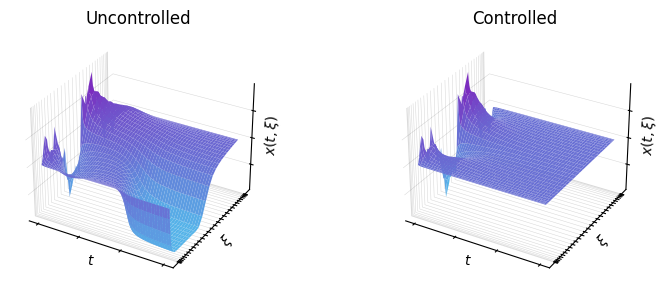

In [ ]:
# Data generation for Allen-Cahn (baseline)
data_ac_train, data_ac_val, meta_ac = load_or_generate(
    config_ac, 
    n_trajectories=100, 
    controller=config_ac.ocp.LQR
)

summary_ac = figures.save_data_summary_table(config_ac, data_ac_train)
display(summary_ac.style.hide(axis="index"))

fig = figures.plot_3d(config=config, controller=config.ocp.LQR)
plt.show()

### Model Training

In [ ]:
# Train controllers on baseline Allen-Cahn
cfg_ac = TrainConfig(batch_size=int(config_ac.n_states), unsup_epochs=3, horizon=100, unsup_n_steps=50)

# 1. Save to LaTeX using the new generic function
figures.save_params_table(cfg, "allen_cahn_traincfg.tex", title="Training Configuration", config=config_ac)

# 2. Show in Notebook using the universal show_spec
figures.show_spec(
    cfg, 
    keys=["sup_epochs", "sup_lr", "unsup_epochs", "unsup_n_steps", "unsup_lr", "horizon", "batch_size", "grad_clip"], 
    title="Training Configuration"
)


trained_models_ac, trained_controllers_ac, histories_ac = train_controllers(
    config=config_ac,
    train_cfg=cfg_ac,
    data=data_ac_train,
    val_data=data_ac_val,
    controller_configs=controller_configs_ac,  # Use the config defined above
)

figures.plot_training_losses(
    series=[(name, hist) for name, hist in histories_ac.items()],
    logy=True,
    smooth="ema",
    ema_alpha=0.03,
    savepath="figures/allen_cahn_loss_curve.pdf",
);

NameError: name 'TrainConfig' is not defined

### Evaluation: Out-of-Sample Generalization

In [ ]:
results = monte_carlo(config.ocp, config, controllers, n_MC=100, dist=1.5)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config)

  2%|▏         | 2/100 [00:02<01:50,  1.13s/it]

Trajectory 0 NOT converged - final_dists[0] = inf


  2%|▏         | 2/100 [00:02<01:37,  1.01it/s]

Trajectory 0 NOT converged - final_dists[0] = inf


  2%|▏         | 2/100 [00:00<00:39,  2.51it/s]

...

  2%|▏         | 2/100 [00:00<00:38,  2.54it/s]

Trajectory 0 NOT converged - final_dists[0] = inf


100%|██████████| 100/100 [01:17<00:00,  1.29it/s]


Controller,Stability (S),Final ||X|| (mean),t_conv (mean),Cost J (mean)
GradQRNet,48.0%,0.0001,13.77,1.3998
GradQRNet (pre/sup),48.0%,0.0001,13.99,1.3915
GradQRNet (sup/ad),48.0%,0.0000,13.23,1.4099
GradQRNet (pre/ad),49.0%,0.0001,13.80,1.4196
GradQRNet (pre/sup/ad),48.0%,0.0001,13.44,1.4109


,Model,Stability $S$,$t_{\text{conv}}$ (mean),Cost $J$ (mean)
0,GradQRNet,0.48,13.766882,1.399788
1,GradQRNet (pre/sup),0.48,13.989828,1.391549
2,GradQRNet (sup/ad),0.48,13.231930,1.409909
3,GradQRNet (pre/ad),0.49,13.799684,1.419599
4,GradQRNet (pre/sup/ad),0.48,13.444552,1.410855


### Evaluation: Robustness

In [ ]:
from simulation import monte_carlo, process_robustness_results

perturbation_variants = [
  #  (None, 0.0, "Baseline"),
    ("advection", 0.05, "Advection (c=0.05)"),
   ("advection", 0.10, "Advection (c=0.10)"),
    ("advection", 0.12, "Advection (c=0.12)"),
]

# Prepare controllers (trained on baseline)
controllers_ac = [
    ("LQR", config_ac.ocp.LQR),
] + [(name, trained_controllers_ac[name]) for name in trained_controllers_ac.keys()]

# Evaluate on each perturbation variant
robustness_results = {}
for pert_type, pert_strength, pert_name in perturbation_variants:
    print(f"\n{'='*60}")
    print(f"Evaluating on: {pert_name} perturbation")
    print(f"{'='*60}")
    
    # Create config for this perturbation variant
    config_eval = create_config(
        system="allen_cahn",
        n_states=32,
        n_controls=3,
        t1_initial=15.0,
        t1_max=60.0,
        seed=config.seed,
        perturbation_type=pert_type,
        perturbation_strength=pert_strength,
    )
    
    # Run Monte Carlo evaluation with baseline-trained controllers
    results = monte_carlo(config_eval.ocp, config_eval, controllers_ac)
    robustness_results[pert_name] = results
    
    # Show results for this variant
    print(f"\nResults on {pert_name}:")
    figures.show_monte_carlo_results(results)


Evaluating on: Advection (c=0.05) perturbation


  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:00<00:48,  2.06it/s]

Trajectory 0 NOT converged - final_dists[0] = inf


  2%|▏         | 2/100 [00:00<00:47,  2.06it/s]

...

  3%|▎         | 3/100 [00:00<00:25,  3.84it/s]

Trajectory 2 NOT converged - final_dists[2] = inf


100%|██████████| 100/100 [00:12<00:00,  8.06it/s]


Results on Advection (c=0.12):


Controller,Stability (S),Final ||X|| (mean),t_conv (mean),Cost J (mean)
LQR,100.0%,0.0003,9.01,0.4927
GradQRNet,100.0%,0.0061,14.24,0.5317
GradQRNet (sup),3.0%,0.0068,8.07,0.0191
GradQRNet (pre),42.0%,0.0079,21.05,0.9014
GradQRNet (pre/sup),100.0%,0.0001,8.24,0.5020
GradQRNet (ad),100.0%,0.0002,8.32,0.4996
GradQRNet (sup/ad),100.0%,0.0001,7.99,0.5064


In [ ]:

controller_names = [name for name, _ in controllers_ac]
robustness_df = process_robustness_results(robustness_results, controller_names)

results = robustness_results
display(robustness_df.style.hide(axis="index"))

# Save to LaTeX
robustness_df.to_latex(
    "allen_cahn_robustness.tex",
    index=False,
    escape=False,
    caption="Perturbation robustness: controllers trained on baseline Allen-Cahn, evaluated on perturbed variants.",
    label="tab:ac-robustness",
)

Controller,Advection (c=0.05) Stab.,Advection (c=0.05) Cost,Advection (c=0.10) Stab.,Advection (c=0.10) Cost,Advection (c=0.12) Stab.,Advection (c=0.12) Cost
LQR,100%,0.57,100%,0.50,100%,0.49
GradQRNet,99%,0.61,97%,0.55,100%,0.53
GradQRNet (sup),2%,0.01,1%,0.01,3%,0.02
GradQRNet (pre),53%,0.93,38%,0.96,42%,0.90
GradQRNet (pre/sup),100%,0.58,100%,0.51,100%,0.50
GradQRNet (ad),100%,0.58,100%,0.50,100%,0.50
GradQRNet (sup/ad),100%,0.58,100%,0.51,100%,0.51


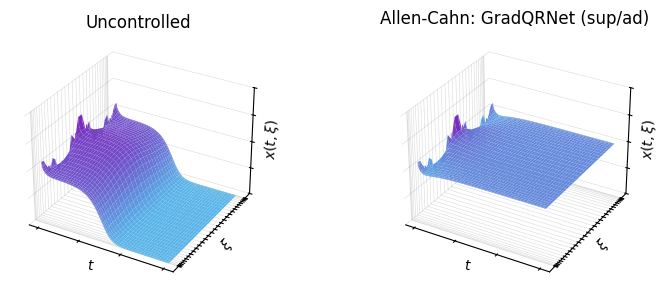

In [ ]:
# Best learned controller
best_ctrl_name = list(trained_controllers_ac.keys())[-1]  # typically AdHOC
fig = figures.plot_3d(config=config_ac, controller=trained_controllers_ac[best_ctrl_name], savepath="figures/allen_cahn_adhoc.pdf")
plt.title(f"Allen-Cahn: {best_ctrl_name}")
plt.show()